# QSVT as a Soft Singular-Value Filter

**Quantum Singular Value Transformation (QSVT)** implements bounded
polynomial filters on singular values.

A smooth alternative to a discontinuous step is the even, bounded polynomial

$$f(x) = x^2,$$

which produces smooth singular-value suppression and is directly compatible
with small educational QSVT examples.

## Variable definitions

- $A$ is the non-negative diagonal toy matrix.
- $\sigma=(\sigma_1,\ldots,\sigma_n)$ is its singular-value vector; $\sigma_i$ is the $i$th singular value and $n$ is the matrix dimension.
- $x\in[-1,1]$ is a generic singular-value input, and $f(x)=x^2$ is the bounded soft-filter polynomial.

## Notebook guide

- **Learning objective:** build and apply a soft singular-value filter.
- **Prerequisites:** an editable repository install plus basic NumPy and linear-algebra familiarity.
- **Estimated runtime:** about 1–3 minutes on a local CPU.
- **Navigation:** [collection index](README.md) · [previous](01_QSVT_Scalar_and_Diagonal_Matrix.ipynb) · [next](03_QSP_Polynomial_Demo.ipynb).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qsvt.polynomials import eval_polynomial, is_bounded_on_interval
from qsvt.qsvt import (
    classical_diagonal_polynomial_transform,
    compare_qsvt_vs_classical_diagonal,
    qsvt_diagonal_transform,
)

## Toy Matrix

Consider a diagonal matrix with singular values

$$\sigma = [1.0,\, 0.7,\, 0.3,\, 0.1].$$

The target polynomial keeps large singular values relatively
large and suppresses small singular values.

Since the matrix is diagonal and non-negative, the diagonal entries are also
its singular values in this simple example.

In [2]:
singular_values = np.array([1.0, 0.7, 0.3, 0.1], dtype=float)
A = np.diag(singular_values)

print(f"A = {A}")

A = [[1.  0.  0.  0. ]
 [0.  0.7 0.  0. ]
 [0.  0.  0.3 0. ]
 [0.  0.  0.  0.1]]


## Polynomial Filter

QSVT-compatible polynomials must satisfy

$$|f(x)| \le 1 \quad \text{for all } x \in [-1,1].$$

A simple bounded filter is

$$f(x) = x^2.$$

This is not a sharp threshold function, but it behaves like a soft filter:

- large singular values remain relatively large,
- small singular values are suppressed more strongly.

Filter coefficients: [0. 0. 1.]
Bounded on [-1,1]: True


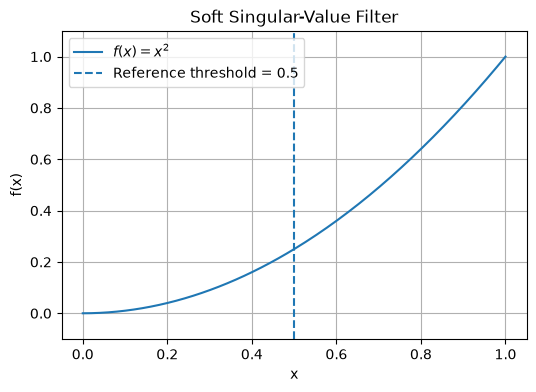

In [3]:
filter_poly = np.array([0.0, 0.0, 1.0])

x = np.linspace(0.0, 1.0, 200)
y = eval_polynomial(filter_poly, x)

print("Filter coefficients:", filter_poly)
print(
    "Bounded on [-1,1]:",
    is_bounded_on_interval(filter_poly, lower=-1.0, upper=1.0, bound=1.0),
)

plt.figure(figsize=(6, 4))
plt.plot(x, y, label=r"$f(x)=x^2$")
plt.axvline(0.5, linestyle="--", label="Reference threshold = 0.5")
plt.ylim(-0.1, 1.1)
plt.title("Soft Singular-Value Filter")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

## Applying the Filter via QSVT

The filter is applied to the diagonal values of `A`.

The package helper `qsvt_diagonal_transform` keeps the example on the tested
package path instead of reimplementing the matrix transformation.

For this 4-entry diagonal example:

- the operator is `4 x 4`, so it uses 2 data qubits,
- embedding-based block encoding needs one additional ancilla qubit,
- the call therefore passes 3 wires explicitly.

In [4]:
encoding_wires = [0, 1, 2]
wire_order = [0, 1, 2]

transformed = qsvt_diagonal_transform(
    singular_values,
    filter_poly,
    encoding_wires=encoding_wires,
    wire_order=wire_order,
)

print(f"Original singular values: {singular_values}")
print(f"Transformed singular values: {np.asarray(transformed)}")

Original singular values: [1.  0.7 0.3 0.1]
Transformed singular values: [1.   0.49 0.09 0.01]


The comparison includes:

- the original singular values $\sigma_i$,
- the QSVT-transformed values,
- the exact classical polynomial values $f(\sigma_i)=\sigma_i^2$.

This gives a soft filtering effect:

- $1.0 \mapsto 1.0$
- $0.7 \mapsto 0.49$
- $0.3 \mapsto 0.09$
- $0.1 \mapsto 0.01$

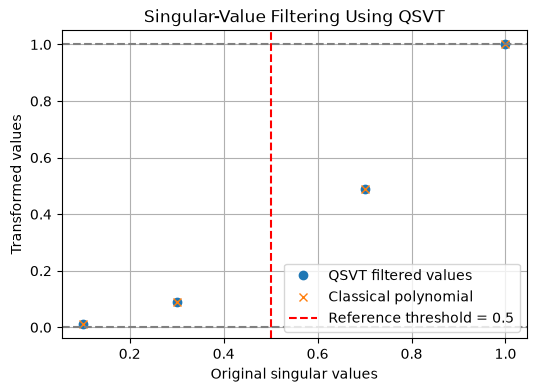

In [5]:
classical_transformed = classical_diagonal_polynomial_transform(
    singular_values,
    filter_poly,
)

plt.figure(figsize=(6, 4))
plt.plot(singular_values, transformed, "o", label="QSVT filtered values")
plt.plot(
    singular_values,
    classical_transformed,
    "x",
    label="Classical polynomial",
)
plt.axhline(0.0, color="grey", linestyle="--")
plt.axhline(1.0, color="grey", linestyle="--")
plt.axvline(0.5, color="red", linestyle="--", label="Reference threshold = 0.5")
plt.xlabel("Original singular values")
plt.ylabel("Transformed values")
plt.title("Singular-Value Filtering Using QSVT")
plt.legend()
plt.grid(True)
plt.show()

The QSVT and classical results should agree closely.

The example establishes the basic filtering pattern:

- choose a bounded polynomial,
- interpret it as a singular-value transform,
- observe how large and small singular values are reshaped differently.

Subsequent tutorials introduce sharper filters and structured polynomial
families.

## Package comparison

`compare_qsvt_vs_classical_diagonal` returns aligned QSVT and classical
values with absolute errors for the same diagonal input.

In [6]:
comparison = compare_qsvt_vs_classical_diagonal(
    singular_values,
    filter_poly,
    encoding_wires=encoding_wires,
    wire_order=wire_order,
)
comparison_rows = [
    {
        "input": sigma,
        "qsvt": qsvt_value,
        "classical": classical_value,
        "abs_error": error,
    }
    for sigma, qsvt_value, classical_value, error in zip(
        comparison["input"],
        comparison["qsvt"],
        comparison["classical"],
        comparison["abs_error"],
    )
]

print("Comparison helper output")
print("------------------------")
print("Input σ | QSVT output | Classical output | abs. error")
print("------- | ----------- | ---------------- | ----------")
for row in comparison_rows:
    print(
        f"{row['input']:.3g} | "
        f"{row['qsvt']:.6g} | "
        f"{row['classical']:.6g} | "
        f"{row['abs_error']:.2e}"
    )

Comparison helper output
------------------------
Input σ | QSVT output | Classical output | abs. error
------- | ----------- | ---------------- | ----------
1 | 1 | 1 | 1.00e-12
0.7 | 0.49 | 0.49 | 4.90e-13
0.3 | 0.09 | 0.09 | 8.98e-14
0.1 | 0.01 | 0.01 | 9.83e-15


## Validation

Compact checks for the expected tutorial behavior.


In [7]:
assert is_bounded_on_interval(filter_poly)
assert np.allclose(transformed, classical_transformed, atol=1e-9)
assert np.max(comparison["abs_error"]) < 1e-9
assert np.all(np.diff(transformed) < 0.0)

print(f"max_abs_error: {np.max(comparison['abs_error']):.3e}")
print("transformed_singular_values:", np.array2string(transformed, precision=4))
print("validation: passed")

max_abs_error: 1.000e-12
transformed_singular_values: [1.   0.49 0.09 0.01]
validation: passed


## Takeaways and next steps

- **Result:** The workflow shows how to build and apply a soft singular-value filter.
- **Interpretation boundary:** Treat simulator-scale circuits and resource proxies according to the truth contract stated in the notebook.
- **Continue:** [collection index](README.md) · [previous](01_QSVT_Scalar_and_Diagonal_Matrix.ipynb) · [next](03_QSP_Polynomial_Demo.ipynb).
